## CHAPTER 7. 합성곱 신경망
<복습>
- 이 전까지의 신경망 = 인접하는 계층의 모든 뉴런과 연결되어 있는 '완전연결(fully-connected)' 계층 = Affine 계층을 가짐
    - input ➡️ Affine ➡️ 활성화함수(ReLU) ➡️ Affine ➡️ 활성화함수(ReLU) ➡️ Affine ➡️ Softmax ➡️ output 

    
### 7-1. 합성곱 신경망의 전체 구조
- ✅합성곱 계층과 ✅풀링 계층이 새롭게 등장함
- input ➡️ Conv ➡️ 활성화함수(ReLU) ➡️ Pooling ➡️ Conv ➡️ 활성화함수 ➡️ Pooling ➡️ Conv ➡️ ReLU ➡️ Affine ...
    - Pooling 계층은 생략 가능
    - 출력에 가까운 층은 Affine ➡️ Softmax 구조를 사용 가능함


### 7-2. 합성곱 계층
- CNN에서는 패딩(Padding), 스트라이드(Stride)등 고유의 용어가 등장함
- 이전까지의 신경망에서는 2차원 데이터가 흘렀지만, **3차원 데이터처럼 입체적인 데이터가 흐름**

#### 7-2-1. 완전연결 계층의 문제점
- 📍 **데이터의 형상이 무시된다는 것**
    - input data = 이미지 데이터인 경우 이미지는 가로,세로,채널로 구성된 3차원 데이터
    - 하지만, 이를 완전연결 계층에 넣는다면 3차원 데이터를 1차원 데이터로 flatten하여 넣어야 함.
    - ✅ 3차원 데이터(이미지 데이터) = 공간적 정보를 담고 있음(가까운 픽셀은 값이 비슷하다는 등..) = 본질적 패턴이 있음

- CNN은 데이터의 형상을 유지함. 즉, 3차원 형태로 데이터가 입력되고, 전달되고, 출력됨
    - 특징맵 = 합성곱 계층의 입출력 데이터 라고 부름

#### 7-2-2. 합성곱 연산
- CNN에서는 입력 데이터에 필터를 적용함
- 입력 데이터(4,4)형상 * 필터(3,3)형상 = (2,2) 출력
- **필터의 매개변수가 완전연결계층의 가중치 역할을 함 + 편향은 나중에 따로 더해짐**

#### 7-2-3. 패딩
- 패딩 = 합성곱 연산을 수행하기 전에 출력 크기를 조절할 목적으로 입력 데이터 주변 값을 0으로 채우는 것
- 합성곱 연산의 경우 합성곱 연산을 진행할수록 그 크기가 작아진다는 문제가 있는데, 이를 해결하기 위함

#### 7-2-4. 스트라이드
- 필터를 적용하는 위치의 간격을 스트라이드라고 함
- 출력 크기 = {(입력 크기 + 2*패딩크기 - 필터크기) / 스트라이드 크기} + 1

#### 7-2-5. 3차원 데이터의 합성곱 연산 
- 채널 쪽으로 특징맵이 여러 개 있다면, 입력 데이터와 필터의 합성곱 연산을 채널마다 수행하고 그 결과를 더해서 하나의 결과를 얻음
    - 입력데이터 (4, 4, 3) * 필터 (3, 3, 3) = 출력 데이터(2, 2)
    - 입력데이터 = 채널이 3개 / 필터도 채널이 3개 ⭐️ **입력 데이터의 채널수와 필터의 채널 수가 같아야함**

#### 7-2-6. 블록으로 생각하기
- ⭐️ **입력 데이터의 채널수와 필터의 채널 수가 같아야함**
##### 그러면, 합성곱 연산의 출력으로 다수의 채널을 내보내려면 어떻게 해야할까????
- ✅ 필터(가중치)를 다수 사용하는 것

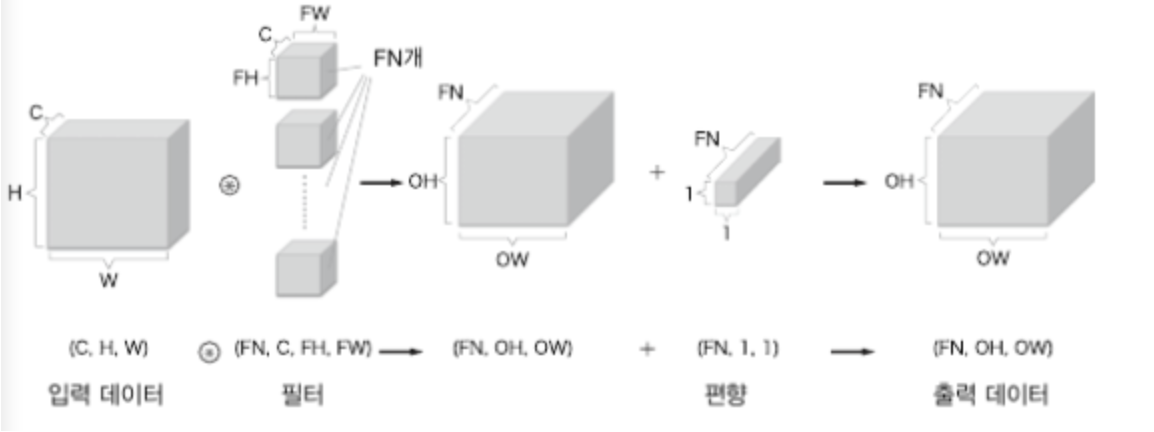


#### 7-2-7. 배치 처리
- 합성곱 신경망에서의 배치처리 방법 = 각 계층을 흐르는 데이터의 차원을 하나 늘려서 저장(3차원 to 4차원)
    - (데이터 수, 채널 수, 높이, 너비) 형태로 저장하며 여기서 **"데이터 수 = 배치 크기"** 가 됨

### 7-3. 풀링 계층
- 풀링(Pooling) = 세로/가로 방향의 공간을 줄이는 연산
- 최대 풀링(Max Pooling) = 정해진 영역에서 가장 큰 원소를 하나 꺼내는 것
- 평균 풀링(Average Pooling) = 정해진 영역의 평균값을 꺼내는 것

#### 7-3-1. 풀링 계층의 특징
- 학습해야할 매개변수가 없음
- 채널 수가 변하지 않음
- 입력의 변화에 영향을 적게 받음 (최대 풀링을 가정했을 때, 최댓값이 바뀌지 않는이상 풀링 결과는 달라지지 X)

### 7-4. 합성곱/풀링 계층 구현하기

#### 7-4-1. 4차원 배열 

In [1]:
import numpy as np

x = np.random.rand(10, 1, 28, 28) #높이, 너비가 28, 28이고 채널은 1, 배치 사이즈가 10인 데이터
print(x.shape)

(10, 1, 28, 28)


In [2]:
print(x[0].shape)
print(x[1].shape)

(1, 28, 28)
(1, 28, 28)


#### 7-4-2 im2col로 데이터 전개하기
- 입력 데이터를 필터링(가중치 계산)하기 좋도록 전개하는 함수
- 3차원 데이터 -> im2col -> 2차원 데이터

#### 7-4-3. 합성곱 계층 구현하기
- im2col(input_data, filter_h, filter_w, stride = 1, pad = 0) 함수를 common/util.py 에 제공
- input_data = (데이터 수, 채널 수, 높이, 너비)의 4차원 배열로 이뤄진 입력 데이터
- filter_h = 필터(커널)의 높이
- filter_w = 필터(커널)의 너비
- stride = 스트라이드
- pad = 패딩

In [3]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

from common.util import im2col

x1 = np.random.rand(1, 3, 7, 7) #x1 데이터는 1개로 이뤄져 있으며, 3채널에 7x7 크기
col1 = im2col(x1, 5, 5, stride=1, pad=0)
print(col1.shape)

x2 = np.random.rand(10, 3, 7, 7) #3채널에 7x7 크기인 데이터가 10개
col2 = im2col(x2, 5, 5, stride=1, pad=0)
print(col2.shape)


(9, 75)
(90, 75)


In [4]:
class Convolution:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W
        self.b = b
        self.stride = stride
        self.pad = pad

    def forward(self, x):
        FN, C, FH, FW = self.W.shape #cnn에서는 가중치(W)가 곧 필터
        N, C, H, W = x.shape
        out_h = int(1 + (H + 2*self.pad - FH) / self.stride)
        out_w = int(1 + (W + 2*self.pad - FW) / self.stride)

        col = im2col(x, FH, FW, self.stride, self.pad)
        col_W = self.W.reshape(FN, -1).T #필터 전개(col이랑 np.dot 연산 진행해야 하기 때문에)
        out = np.dot(col, col_W) + self.b

        out = out.reshape(N, out_h, out_w, -1).transpose(0, 3, 1, 2)

        return out


#### 7-4-4. 풀링 계층 구현하기

In [5]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=2, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad

    def forward(self, x):
        N, C, H, W = x.shape
        out_h = int(1 + (H - self.pool_h) / self.stride)
        out_w = int(1 + (H - self.pool_w) / self.stride)

        col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
        col = col.reshape(-1, self.pool_h*self.pool_w)

        out = np.max(col, axis = 1)

        out = out.reshape(N, out_h, out_w, C).transpose(0,3,1,2)

        return out

### 7-5. CNN 구현하기

In [ ]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import pickle
import numpy as np
from collections import OrderedDict
from common.layers import *
from common.gradient import numerical_gradient


class SimpleConvNet:
    """단순한 합성곱 신경망
    
    conv - relu - pool - affine - relu - affine - softmax
    
    Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    """
    def __init__(self, input_dim=(1, 28, 28), 
                 conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                 hidden_size=100, output_size=10, weight_init_std=0.01):
        filter_num = conv_param['filter_num']
        filter_size = conv_param['filter_size']
        filter_pad = conv_param['pad']
        filter_stride = conv_param['stride']
        input_size = input_dim[1]
        conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))

        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * \
                            np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(pool_output_size, hidden_size)
        self.params['b2'] = np.zeros(hidden_size)
        self.params['W3'] = weight_init_std * \
                            np.random.randn(hidden_size, output_size)
        self.params['b3'] = np.zeros(output_size)

        # 계층 생성
        self.layers = OrderedDict()
        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'],
                                           conv_param['stride'], conv_param['pad'])
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2'])
        self.layers['Relu2'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3'])

        self.last_layer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """손실 함수를 구한다.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블
        """
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1 : t = np.argmax(t, axis=1)
        
        acc = 0.0
        
        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i*batch_size:(i+1)*batch_size]
            tt = t[i*batch_size:(i+1)*batch_size]
            y = self.predict(tx)
            y = np.argmax(y, axis=1)
            acc += np.sum(y == tt) 
        
        return acc / x.shape[0]

    def numerical_gradient(self, x, t):
        """기울기를 구한다（수치미분）.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        loss_w = lambda w: self.loss(x, t)

        grads = {}
        for idx in (1, 2, 3):
            grads['W' + str(idx)] = numerical_gradient(loss_w, self.params['W' + str(idx)])
            grads['b' + str(idx)] = numerical_gradient(loss_w, self.params['b' + str(idx)])

        return grads

    def gradient(self, x, t):
        """기울기를 구한다(오차역전파법).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        # 순전파
        self.loss(x, t)

        # 역전파
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads
        
    def save_params(self, file_name="params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params.pkl"):
        with open(os.path.dirname(__file__) + '/' + file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, key in enumerate(['Conv1', 'Affine1', 'Affine2']):
            self.layers[key].W = self.params['W' + str(i+1)]
            self.layers[key].b = self.params['b' + str(i+1)]